In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

air_quality = pd.read_csv("city_day.csv")
crop_production = pd.read_csv("crop_production.csv")


In [6]:
# Task 6 : AQI Trend Over Years
# Convert Date column into datetime
air_quality["Date"] = pd.to_datetime(air_quality["Date"])
air_quality["Year"] = air_quality["Date"].dt.year
air_quality[["Date","Year"]].head()

,Date,Year
0,2015-01-01,2015
1,2015-01-02,2015
2,2015-01-03,2015
3,2015-01-04,2015
4,2015-01-05,2015


In [7]:
yearly_aqi = (
    air_quality
    .groupby("Year")["AQI"]
    .mean()
    .reset_index()
)

yearly_aqi

,Year,AQI
0,2015,212.463054
1,2016,197.150019
2,2017,181.472789
3,2018,182.684312
4,2019,156.518173
5,2020,113.520697


In [8]:
highest = yearly_aqi[
    yearly_aqi["AQI"] ==
    yearly_aqi["AQI"].max()
]

lowest = yearly_aqi[
    yearly_aqi["AQI"] ==
    yearly_aqi["AQI"].min()
]

print("Most polluted year:")
print(highest)

print("Least polluted year:")
print(lowest)

Most polluted year:
   Year         AQI
0  2015  212.463054
Least polluted year:
   Year         AQI
5  2020  113.520697


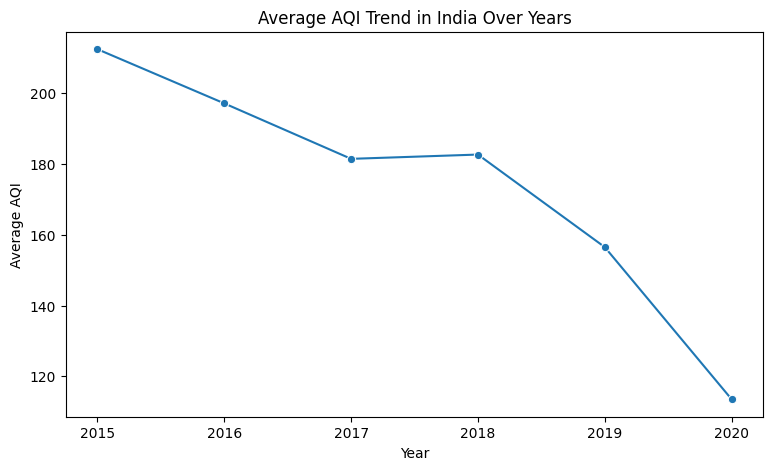

In [9]:
plt.figure(figsize=(9,5))

sns.lineplot(
    data=yearly_aqi,
    x="Year",
    y="AQI",
    marker="o"
)

plt.title(
    "Average AQI Trend in India Over Years"
)

plt.xlabel("Year")
plt.ylabel("Average AQI")

plt.show()

A line plot was selected because it clearly represents changes in AQI
over time.

The analysis shows that AQI values changed across years instead of
remaining constant. The highest AQI year represents the period with the
worst air quality, while the lowest AQI year indicates comparatively
cleaner air.

The trend suggests whether pollution control measures after 2018 were
associated with improvement or decline in air quality. However, AQI alone
cannot prove that policies caused the change because weather and human
activities also influence pollution.

In [ ]:
#( TASK 3 )
for df in [air_quality, crop_production]:
    for col in df.select_dtypes(include=['object']).columns:
        df[col] = df[col].str.strip().str.title()


state_map = {
    'Ahmedabad': 'Gujarat', 'Aizawl': 'Mizoram', 'Amaravati': 'Andhra Pradesh',
    'Amritsar': 'Punjab', 'Bengaluru': 'Karnataka', 'Bhopal': 'Madhya Pradesh',
    'Brajrajnagar': 'Odisha', 'Chandigarh': 'Chandigarh', 'Chennai': 'Tamil Nadu',
    'Coimbatore': 'Tamil Nadu', 'Delhi': 'Delhi', 'Ernakulam': 'Kerala',
    'Gurugram': 'Haryana', 'Guwahati': 'Assam', 'Hyderabad': 'Telangana',
    'Jaipur': 'Rajasthan', 'Jorapokhar': 'Jharkhand', 'Kochi': 'Kerala',
    'Kolkata': 'West Bengal', 'Lucknow': 'Uttar Pradesh', 'Mumbai': 'Maharashtra',
    'Patna': 'Bihar', 'Shillong': 'Meghalaya', 'Talcher': 'Odisha',
    'Thiruvananthapuram': 'Kerala', 'Visakhapatnam': 'Andhra Pradesh'
}

air_quality['State_Name'] = air_quality['City'].map(state_map)

print(f"Records in Crop Data before: {len(crop_production)}")
crop_production.drop_duplicates(inplace=True)
print(f"Records in Crop Data after: {len(crop_production)}")

print(f"Records in AQI Data before: {len(air_quality)}")
air_quality.drop_duplicates(inplace=True)
print(f"Records in AQI Data after: {len(air_quality)}")

Records in Crop Data before: 246091
Records in Crop Data after: 246091
Records in AQI Data before: 29531
Records in AQI Data after: 29531


TASK 7:

In [12]:
air_quality["Month"] = air_quality["Date"].dt.month
monthly_aqi = (air_quality.groupby("Month")["AQI"].mean().reset_index())
monthly_aqi

,Month,AQI
0,1,231.674918
1,2,202.905197
2,3,164.735281
3,4,143.355120
4,5,135.489579
5,6,120.198379
6,7,111.854575
7,8,113.613176
8,9,115.191804
9,10,188.613552


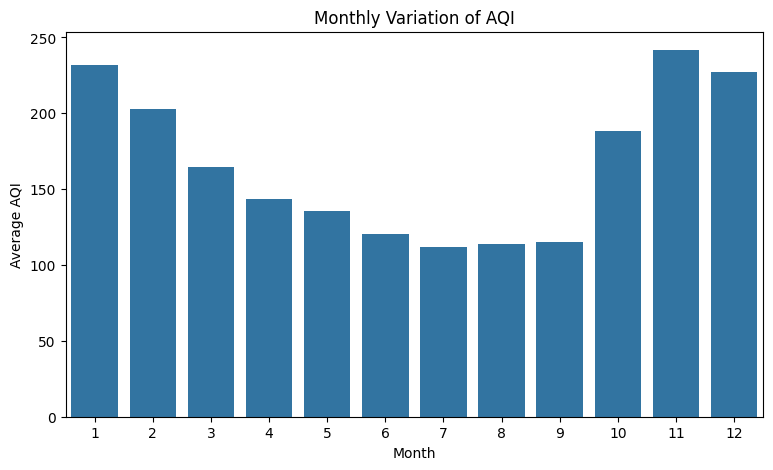

In [16]:
plt.figure(figsize=(9,5))

sns.barplot(
    data=monthly_aqi,
    x="Month",
    y="AQI"
)

plt.title(
    "Monthly Variation of AQI"
)

plt.xlabel("Month")
plt.ylabel("Average AQI")

plt.show()

TASK 8 :
Direct merging is not possible because both datasets have different
levels of detail.

AQI Dataset:
- Recorded daily at city level

Crop Dataset:
- Recorded yearly at state level

To make them compatible, AQI values are converted into average yearly
AQI for each state.

After transformation, both datasets contain State and Year information
and can be merged correctly.

In [17]:
state_aqi_avg = (air_quality.groupby("State_Name")["AQI"].mean().reset_index())
state_crop_avg = (crop_production.groupby("State_Name")[["Area","Production"]].mean().reset_index())
merged_df = pd.merge(state_crop_avg,state_aqi_avg,on="State_Name",how="inner")
print("Merged Dataset Shape:",merged_df.shape)
merged_df.head()

Merged Dataset Shape: (20, 4)


,State_Name,Area,Production,AQI
0,Andhra Pradesh,13662.842127,1.812006e+06,108.086481
1,Assam,4811.235849,1.444229e+05,140.111111
2,Bihar,6792.270638,1.941738e+04,240.782042
3,Chandigarh,139.133333,7.186124e+02,96.498328
4,Gujarat,18367.001422,6.267679e+04,452.122939


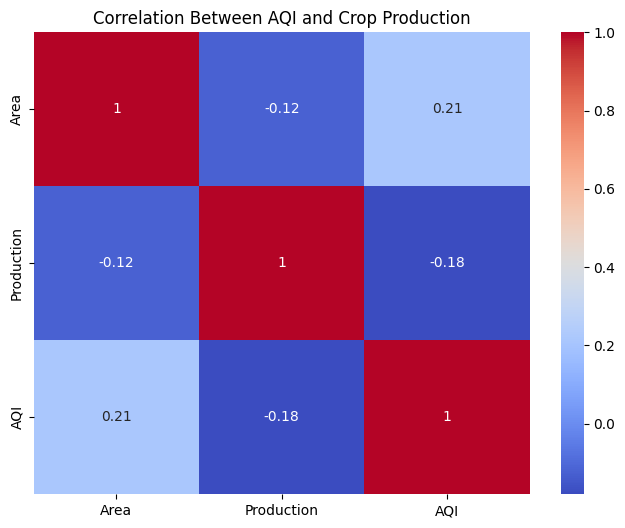

In [18]:
corr_matrix = (
    merged_df[
        ["Area","Production","AQI"]
    ]
    .corr()
)


plt.figure(figsize=(8,6))


sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm"
)


plt.title(
    "Correlation Between AQI and Crop Production"
)


plt.show()

Relationship Analysis:

1. AQI vs Production:
The correlation value is -0.18, showing a weak negative relationship.
This means higher pollution levels are slightly associated with lower
crop production, but the effect is not strong.

2. AQI vs Area:
The correlation value is 0.23, showing a weak positive relationship.
States with larger agricultural areas may have slightly higher AQI due
to factors like farming activities, industries, and transportation.

Note:
Correlation does not prove that pollution directly reduces crop yield.
Other factors such as rainfall, irrigation, soil quality, and crop type
also affect agricultural production.

To : State Environment Minster
Subject : Addressing the Air - Quality Agriculture Nexus in india 


Our analysis studied India's air quality and agricultural production
data to understand environmental patterns.

The first finding is that air pollution levels have changed over time.
Some years recorded higher AQI levels, showing that continuous pollution
monitoring is important.

The second finding is that air quality changes with seasons. Certain
months show higher pollution levels, meaning farmers and citizens may
experience worse air conditions during specific periods.

The third finding is that crop production and pollution show some
relationships, but agricultural output depends on many factors.

Based on this analysis, one recommended action is to improve pollution
control measures during high AQI months and encourage cleaner farming
practices.

However, this data cannot prove that air pollution alone reduces crop
production. Factors such as rainfall, irrigation facilities, soil
quality and farming methods also strongly influence agricultural
results.

More detailed studies are needed before making final policy decisions.

Optional — task

The selected visualization is the correlation heatmap because it
summarizes the relationship between air quality and agricultural
variables in a single view.

This chart helps understand whether states with higher pollution levels
also show differences in crop production.

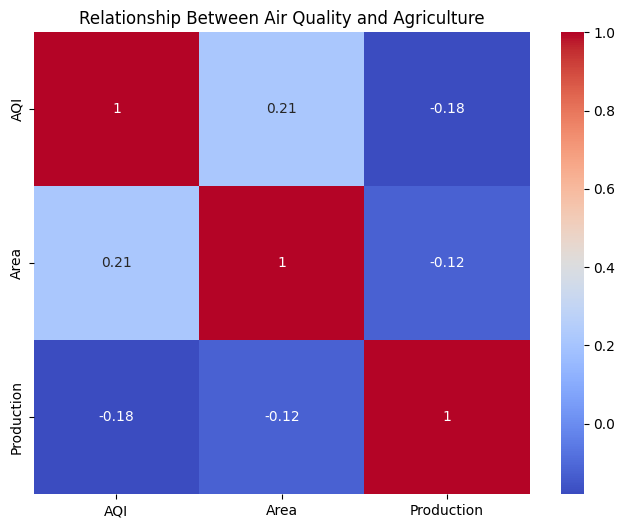

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(merged_df[["AQI","Area","Production"]].corr(),annot=True,cmap="coolwarm")
plt.title("Relationship Between Air Quality and Agriculture")
plt.show()

This visualization highlights the connection between air pollution and
agricultural factors across Indian states.

It helps identify whether highly polluted regions also show changes in
crop production patterns.

The relationship is not enough to conclude that pollution directly
causes lower crop yield because agriculture is also affected by rainfall,
irrigation facilities, soil quality and farming practices.

The chart provides an initial direction for deeper environmental and
agricultural research.

OPTIONAL TASK B: Relationship Strength Between AQI and Crop Production

The main hypothesis is that states with higher pollution may have
lower agricultural production.

To test this relationship, correlation analysis is performed between
average AQI and crop production.

Correlation is selected because it measures both:
1. Direction of relationship
   - Positive: both variables increase together
   - Negative: one increases while the other decreases

2. Strength of relationship
   - Values closer to 1 or -1 show stronger relationships
   - Values near 0 show weak relationships

However, correlation only shows association and does not prove that
pollution causes changes in crop production.

In [20]:
aqi_crop_corr = (merged_df["AQI"].corr(merged_df["Production"]))
print("Correlation between AQI and Production:",aqi_crop_corr)

Correlation between AQI and Production: -0.18036761536447893


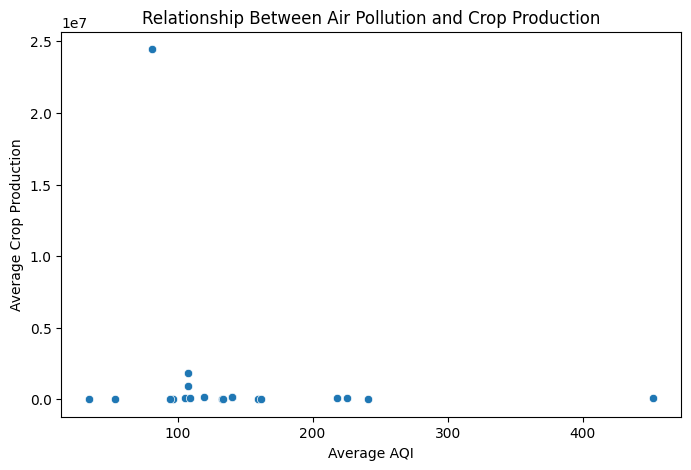

In [21]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=merged_df,x="AQI",y="Production")
plt.title("Relationship Between Air Pollution and Crop Production")
plt.xlabel("Average AQI")
plt.ylabel("Average Crop Production")
plt.show()

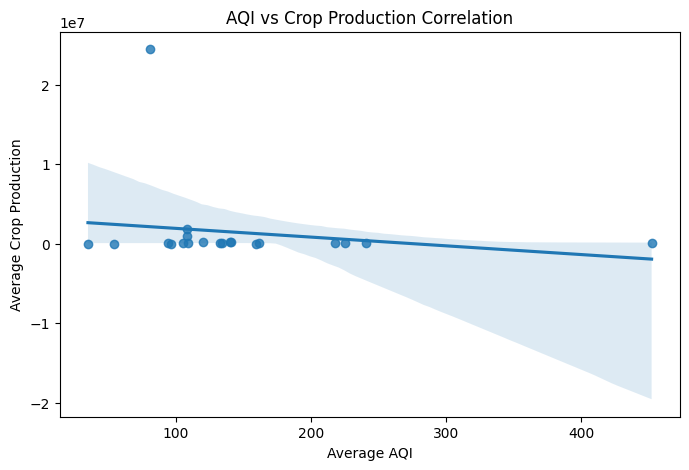

In [22]:
plt.figure(figsize=(8,5))
sns.regplot(
    data=merged_df,
    x="AQI",
    y="Production"
)
plt.title("AQI vs Crop Production Correlation")
plt.xlabel("Average AQI")
plt.ylabel("Average Crop Production")
plt.show()

The correlation between average AQI and crop production is -0.18.

The scatter plot and regression line show a weak negative relationship
between pollution and agricultural output.

The downward trend suggests that states with higher AQI values may have
slightly lower crop production, which provides limited support for the
hypothesis that pollution affects agriculture.

However, the points are widely scattered and the correlation value is
close to zero, showing that AQI is not the only factor influencing crop
production.

This analysis does not prove that pollution causes lower crop yield.
Agriculture also depends on rainfall, irrigation facilities, soil
quality, crop type and economic conditions.

A more detailed study including these factors is required before
confirming a direct impact of air pollution on farming.